# Loan Approval Synthetic Dataset Analysis and Training

## Objective
This notebook performs data understanding, preprocessing, model training, model comparison, and deployment artifact generation for the synthetic loan approval dataset.

## Dataset
`../Dataset/LoanApprovalSynthetic/loan_approval_dataset.csv`

## Deployment Goal
The final saved files from this notebook are:
- `artifacts/preprocessor.pkl`
- `artifacts/model.pkl`
- `artifacts/synthetic_model_results.csv`

These are the files used by the Flask application during prediction.

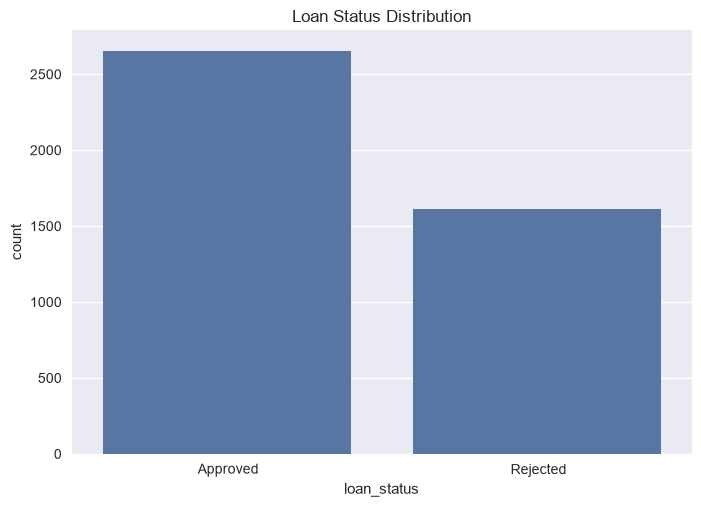

In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
plt.style.use("seaborn-v0_8")
df = pd.read_csv("../Dataset/LoanApprovalSynthetic/loan_approval_dataset.csv")

df = df.copy()
df.columns = df.columns.str.strip()

df.head()
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()

In [27]:
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


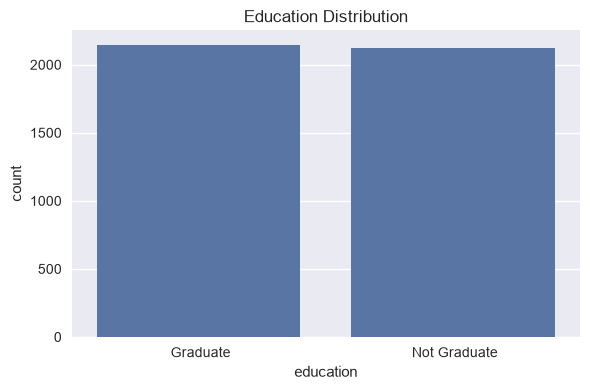

In [28]:
# Education Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="education", data=df)
plt.title("Education Distribution")
plt.xticks()
plt.tight_layout()
plt.show()

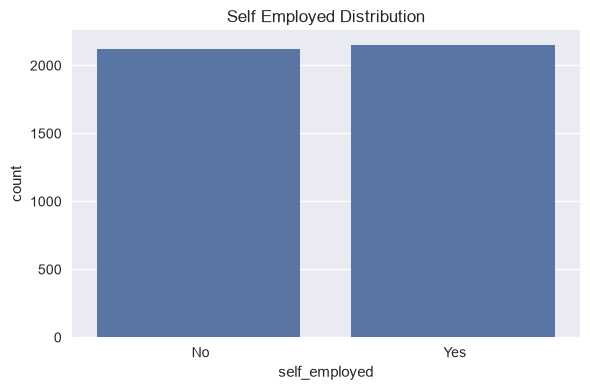

In [29]:
# Self Employed Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="self_employed", data=df)
plt.title("Self Employed Distribution")
plt.xticks()
plt.tight_layout()
plt.show()

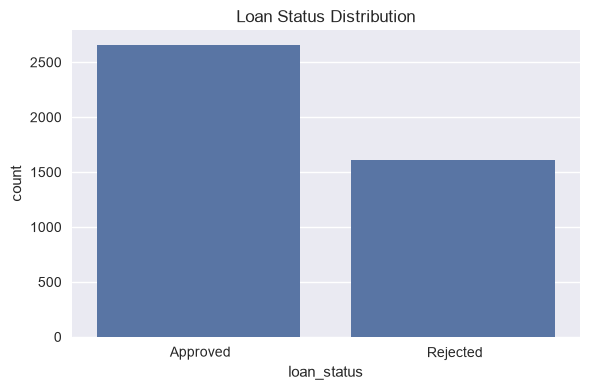

In [30]:
# Loan Status Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.xticks()
plt.tight_layout()
plt.show()

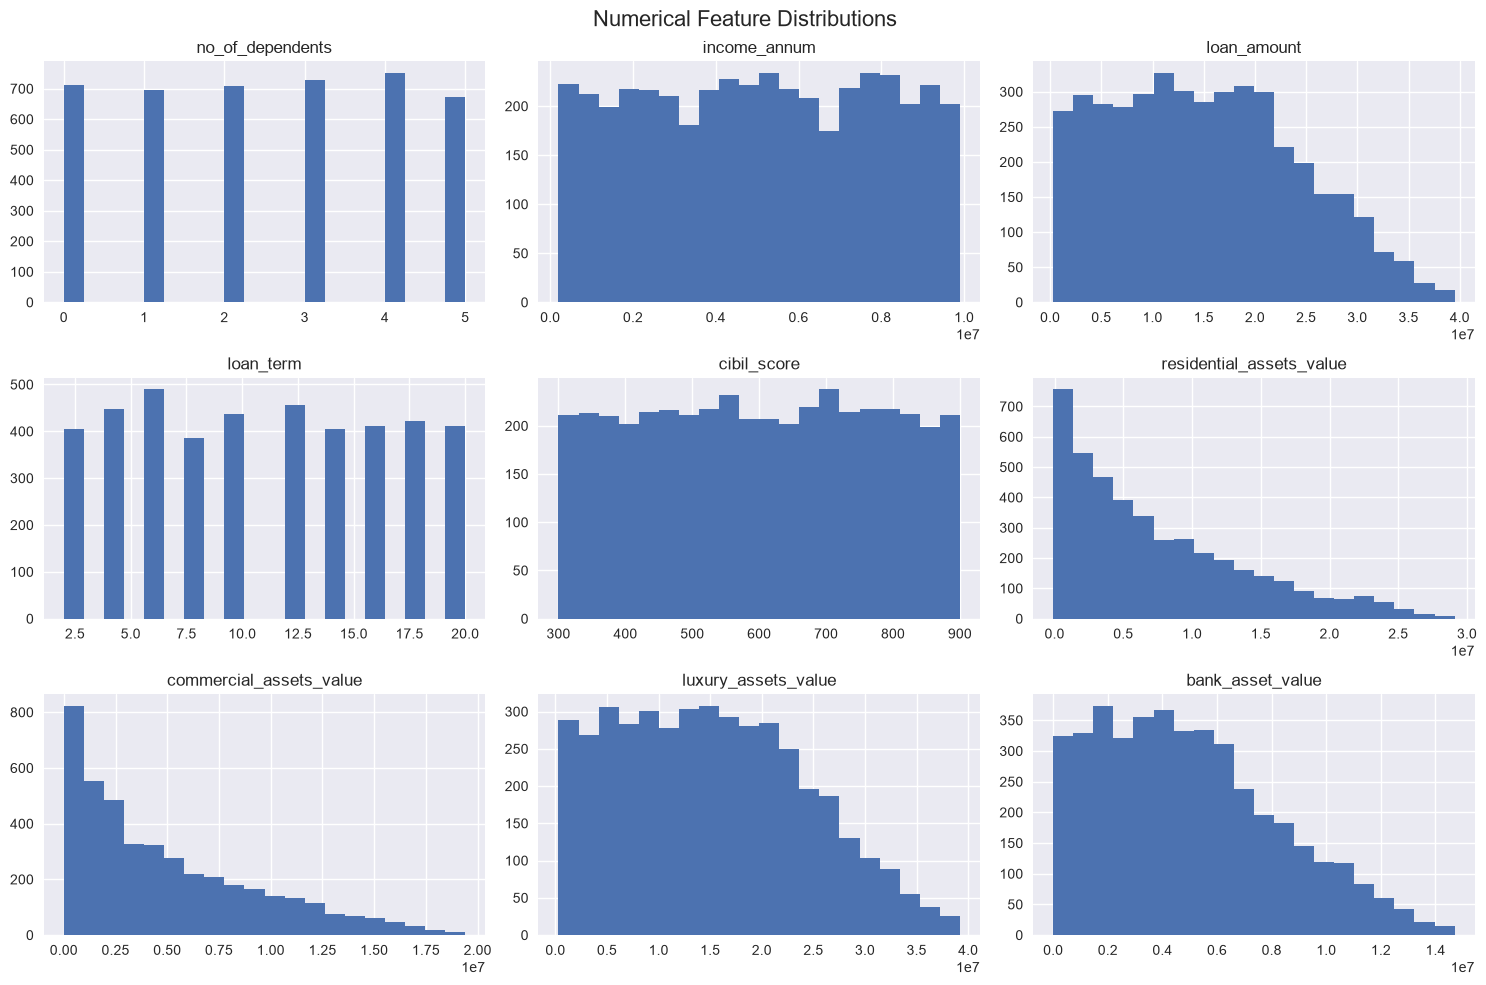

In [31]:
numeric_cols = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

df[numeric_cols].hist(figsize=(15, 10), bins=20)
plt.suptitle("Numerical Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

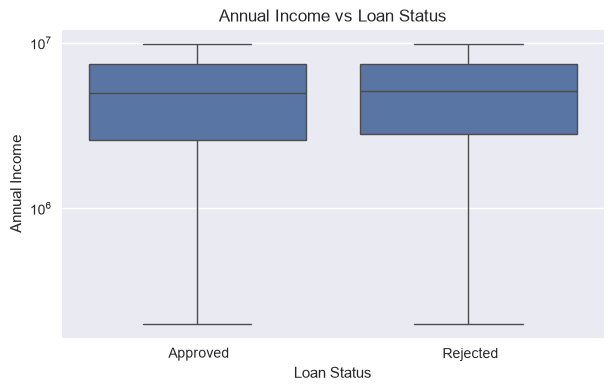

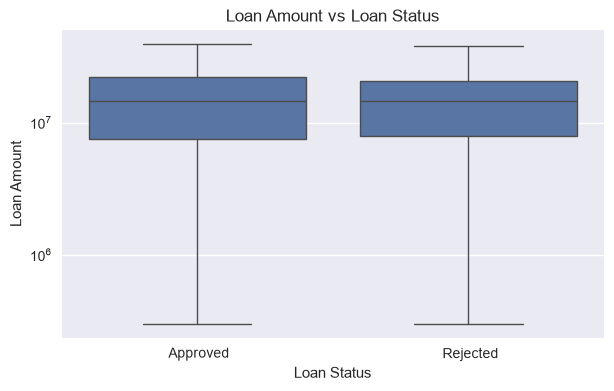

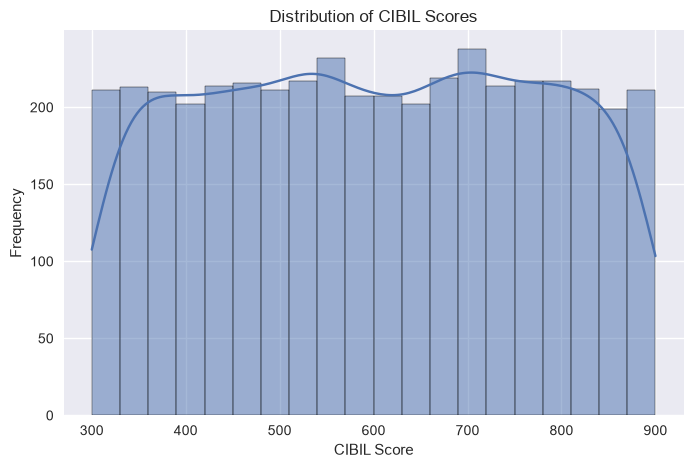

In [32]:
plot_df = df.copy()

# Income vs Loan Status
plt.figure(figsize=(7,4))
sns.boxplot(x="loan_status", y="income_annum", data=plot_df)
plt.yscale("log")
plt.title("Annual Income vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")
plt.show()

# Loan Amount vs Loan Status
plt.figure(figsize=(7,4))
sns.boxplot(x="loan_status", y="loan_amount", data=plot_df)
plt.yscale("log")
plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

# CIBIL Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["cibil_score"], bins=20, kde=True)

plt.title("Distribution of CIBIL Scores")
plt.xlabel("CIBIL Score")
plt.ylabel("Frequency")
plt.show()

In [33]:
from pathlib import Path

import joblib
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

ROOT = Path.cwd().resolve().parent if Path.cwd().name.lower() == "notebook" else Path.cwd().resolve()
DATASET_PATH = ROOT / "Dataset" / "LoanApprovalSynthetic" / "loan_approval_dataset.csv"
ARTIFACTS_DIR = ROOT / "artifacts"
SYNTHETIC_ARTIFACTS_DIR = ARTIFACTS_DIR / "LoanApprovalSynthetic"

ARTIFACTS_DIR.mkdir(exist_ok=True)
SYNTHETIC_ARTIFACTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATASET_PATH)
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [34]:
print("Dataset path:", DATASET_PATH)
print("Shape:", df.shape)
print("\nColumns before cleaning:\n", df.columns.tolist())
df.info()

Dataset path: C:\Users\varun\private\project\Loan_Pridiction\Dataset\LoanApprovalSynthetic\loan_approval_dataset.csv
Shape: (4269, 13)

Columns before cleaning:
 ['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibi

## Data Cleaning
- Strip extra spaces from column names and text values.
- Remove duplicate rows if present.
- Drop `loan_id` because it is only an identifier and should not influence model learning.

In [35]:
clean_df = df.copy()
clean_df.columns = clean_df.columns.str.strip()

object_columns = clean_df.select_dtypes(include=["object", "string"]).columns
for column in object_columns:
    clean_df[column] = clean_df[column].str.strip()

print("Missing values before cleaning:\n", clean_df.isnull().sum())
print("\nDuplicate rows before cleaning:", clean_df.duplicated().sum())

clean_df = clean_df.drop_duplicates().copy()
clean_df = clean_df.drop(columns=["loan_id"])

print("\nShape after cleaning:", clean_df.shape)
clean_df.head()

Missing values before cleaning:
 loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Duplicate rows before cleaning: 0

Shape after cleaning: (4269, 12)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [36]:
print(clean_df["education"].value_counts())
print()
print(clean_df["self_employed"].value_counts())
print()
print(clean_df["loan_status"].value_counts())

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


## Feature Setup
The deployed application sends the following 11 input features, so the training pipeline must use the same schema.

In [37]:
target_column = "loan_status"
categorical_features = ["education", "self_employed"]
numerical_features = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
]

X = clean_df[categorical_features + numerical_features]
y = clean_df[target_column]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (4269, 11)
Target vector shape: (4269,)


In [38]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training features shape after preprocessing:", X_train_processed.shape)
print("Testing features shape after preprocessing:", X_test_processed.shape)

Training features shape after preprocessing: (3415, 13)
Testing features shape after preprocessing: (854, 13)


## Model Training and Comparison
We train three classifiers and compare them using accuracy, precision, recall, and F1 score.

In [39]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_split=10),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        min_samples_split=4,
        min_samples_leaf=2,
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    predictions = model.predict(X_test_processed)
    fitted_models[name] = model
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, pos_label="Approved"),
        "Recall": recall_score(y_test, predictions, pos_label="Approved"),
        "F1 Score": f1_score(y_test, predictions, pos_label="Approved"),
    })
    print(f"\n{name} Classification Report\n")
    print(classification_report(y_test, predictions))

results_df = pd.DataFrame(results).sort_values(by=["F1 Score", "Accuracy"], ascending=False).reset_index(drop=True)
results_df


Logistic Regression Classification Report

              precision    recall  f1-score   support

    Approved       0.93      0.95      0.94       531
    Rejected       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854


Decision Tree Classification Report

              precision    recall  f1-score   support

    Approved       0.97      0.99      0.98       531
    Rejected       0.99      0.95      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854


Random Forest Classification Report

              precision    recall  f1-score   support

    Approved       0.98      1.00      0.99       531
    Rejected       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.984778,0.979630,0.996234,0.987862
1,Decision Tree,0.977752,0.970588,0.994350,0.982326
2,Logistic Regression,0.922717,0.926606,0.951036,0.938662


In [40]:
best_model_name = results_df.loc[0, "Model"]
best_model = fitted_models[best_model_name]

print("Best model:", best_model_name)
print(results_df.loc[0])

Best model: Random Forest
Model        Random Forest
Accuracy          0.984778
Precision          0.97963
Recall            0.996234
F1 Score          0.987862
Name: 0, dtype: object


## Save Deployment Artifacts
The following cell saves the preprocessing object and best model using the exact artifact names expected by the Flask app.

In [41]:
results_path = ARTIFACTS_DIR / "synthetic_model_results.csv"
preprocessor_path = ARTIFACTS_DIR / "preprocessor.pkl"
model_path = ARTIFACTS_DIR / "model.pkl"
synthetic_model_path = SYNTHETIC_ARTIFACTS_DIR / "best_loan_model.pkl"

results_df.to_csv(results_path, index=False)
joblib.dump(preprocessor, preprocessor_path)
joblib.dump(best_model, model_path)
joblib.dump(best_model, synthetic_model_path)

print("Saved:", results_path)
print("Saved:", preprocessor_path)
print("Saved:", model_path)
print("Saved:", synthetic_model_path)

Saved: C:\Users\varun\private\project\Loan_Pridiction\artifacts\synthetic_model_results.csv
Saved: C:\Users\varun\private\project\Loan_Pridiction\artifacts\preprocessor.pkl
Saved: C:\Users\varun\private\project\Loan_Pridiction\artifacts\model.pkl
Saved: C:\Users\varun\private\project\Loan_Pridiction\artifacts\LoanApprovalSynthetic\best_loan_model.pkl


In [24]:
sample_prediction = best_model.predict(preprocessor.transform(X_test.head(5)))
comparison_df = X_test.head(5).copy()
comparison_df["actual_status"] = y_test.head(5).values
comparison_df["predicted_status"] = sample_prediction
comparison_df.head(10)

,education,self_employed,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,actual_status,predicted_status
2346,Graduate,No,3,8000000,26200000,16,890,15800000,4300000,25000000,4000000,Approved,Approved
1162,Graduate,Yes,1,1900000,4200000,4,620,4700000,2800000,7500000,900000,Approved,Approved
3061,Not Graduate,Yes,2,3300000,9600000,18,896,9900000,900000,12100000,4900000,Approved,Approved
483,Not Graduate,Yes,3,2500000,8800000,12,538,4900000,1800000,9100000,3300000,Rejected,Rejected
2102,Not Graduate,No,1,7900000,29300000,2,771,17600000,12800000,20400000,4000000,Approved,Approved


## Conclusion
- This notebook trains the model only on `Dataset/LoanApprovalSynthetic/loan_approval_dataset.csv`.
- The saved deployment artifacts are generated from the same synthetic dataset.
- After running the notebook, the Flask app can load `artifacts/preprocessor.pkl` and `artifacts/model.pkl` directly.